In [1]:
import pandas as pd
import numpy as np 
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import json
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")

In [4]:
df.head()

,group,time,time_sec,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id
0,group01,2026-05-08 10:40:43.047895,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
1,group01,2026-05-08 10:40:43.195317,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
2,group01,2026-05-08 10:40:43.295405,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
3,group01,2026-05-08 10:40:43.395835,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [4]:
df[['attention', 'heart_rate', 'gender', 'age']].isna().sum()

attention     0
heart_rate    0
gender        0
age           0
dtype: int64

In [7]:
SEED = 42
SEQUENCE_LENGTH = 10
MAX_MISSING_VISUAL_FRAMES = 3

sensor_cols = [
    col for col in df.columns
    if (
        "sensor" in col.lower()
        or "acceleration" in col.lower()
        or "gyro" in col.lower()
        or "rotation" in col.lower()
        or "heart" in col.lower()
        or "light" in col.lower()
        or "accel" in col.lower()
    )
    and 'std' not in col.lower()
]

len(sensor_cols), sensor_cols[:5]

(15,
 ['samsung_rotation_vector value0_mean',
  'samsung_rotation_vector value1_mean',
  'samsung_rotation_vector value2_mean',
  'samsung_rotation_vector value3_mean',
  'samsung_rotation_vector value4_mean'])

In [8]:
df_sec = (
    df.sort_values(["subject_experiment_id", "time_sec"])
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index()
)


reconstructed_sequences = []

for sequence_id, sequence_df in df_sec.groupby("subject_experiment_id"):
    sequence_df = sequence_df.sort_values("time_sec")

    complete_seconds = pd.DataFrame({
        "time_sec": np.arange(
            sequence_df["time_sec"].min(),
            sequence_df["time_sec"].max() + 1
        )
    })

    reconstructed = complete_seconds.merge(
        sequence_df,
        on="time_sec",
        how="left"
    )

    reconstructed["subject_experiment_id"] = sequence_id
    reconstructed_sequences.append(reconstructed)

temporal_frame_dataset = pd.concat(reconstructed_sequences, ignore_index=True)


sequence_metadata = (
    df[["subject_experiment_id", "subject_id", "gender", "age"]]
    .drop_duplicates("subject_experiment_id")
)


# Only metadata is restored for reconstructed missing seconds, so we can split and
# report fairness. Sensor/image/target values remain missing unless observed.
temporal_frame_dataset = temporal_frame_dataset.drop(
    columns=["subject_id", "gender", "age"],
    errors="ignore"
).merge(sequence_metadata, on="subject_experiment_id", how="left")

temporal_frame_dataset["visual_missing"] = temporal_frame_dataset["image_path"].isna().astype(np.float32)

# A sensor timestep is missing when the whole sensor modality is absent. Partial
# NaNs are handled after train-set scaling by converting them to zero values.
temporal_frame_dataset["sensor_missing"] = temporal_frame_dataset[sensor_cols].isna().all(axis=1).astype(np.float32)
temporal_frame_dataset["sensor_partial_nan"] = (
    temporal_frame_dataset[sensor_cols].isna().any(axis=1)
    & ~temporal_frame_dataset[sensor_cols].isna().all(axis=1)
).astype(np.float32)

temporal_frame_dataset[["subject_experiment_id", "time_sec", "visual_missing", "sensor_missing", "sensor_partial_nan", "attention"]].head()

,subject_experiment_id,time_sec,visual_missing,sensor_missing,sensor_partial_nan,attention
0,group01_experiment01_subject_01,0,0.0,0.0,0.0,3.25
1,group01_experiment01_subject_01,1,0.0,0.0,0.0,3.00
2,group01_experiment01_subject_01,2,0.0,0.0,0.0,3.00
3,group01_experiment01_subject_01,3,0.0,0.0,0.0,3.25
4,group01_experiment01_subject_01,4,0.0,0.0,0.0,3.25


In [15]:
subject_df = temporal_frame_dataset[["subject_id", "gender"]].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df["gender"],
    random_state=SEED)

val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub["gender"],
    random_state=SEED)

train_subjects = train_sub["subject_id"]
val_subjects = val_sub["subject_id"]
test_subjects = test_sub["subject_id"]

train_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(train_subjects)].copy()
val_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(val_subjects)].copy()
test_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(test_subjects)].copy()

# Train-only sensor normalization. Means/stds are computed column-wise from the training split. 
# Missing sensor values become 0 after standardization; 
# the sensor_missing flag still tells the model when the whole sensor timestep was absent.
sensor_means = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].mean()
sensor_stds = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].std()
sensor_stds = sensor_stds.replace(0, np.nan).fillna(1.0)
sensor_means = sensor_means.fillna(0.0)


def apply_sensor_scaling(frame_df):
    frame_df = frame_df.copy()
    scaled = ((frame_df[sensor_cols] - sensor_means) / sensor_stds).astype(np.float32)
    scaled = scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scaled.loc[frame_df["sensor_missing"] == 1, :] = 0.0
    frame_df["sensor_vector"] = list(scaled.to_numpy(dtype=np.float32))
    return frame_df

train_frames = apply_sensor_scaling(train_frames)
val_frames = apply_sensor_scaling(val_frames)
test_frames = apply_sensor_scaling(test_frames)

SENSOR_INPUT_DIM = len(sensor_cols) + 1  # +1 for sensor_missing flag

pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_frames), len(val_frames), len(test_frames)],
    "subjects": [train_frames.subject_id.nunique(), val_frames.subject_id.nunique(), test_frames.subject_id.nunique()],
    "target_mean": [train_frames.attention.mean(), val_frames.attention.mean(), test_frames.attention.mean()],
    "sensor_missing_rate": [train_frames.sensor_missing.mean(), val_frames.sensor_missing.mean(), test_frames.sensor_missing.mean()],
    "sensor_partial_nan_rate": [train_frames.sensor_partial_nan.mean(), val_frames.sensor_partial_nan.mean(), test_frames.sensor_partial_nan.mean()],
    "visual_missing_rate": [train_frames.visual_missing.mean(), val_frames.visual_missing.mean(), test_frames.visual_missing.mean()],
})


,split,rows,subjects,target_mean,sensor_missing_rate,sensor_partial_nan_rate,visual_missing_rate
0,train,83995,39,2.929250,0.079707,0.00006,0.079707
1,val,18239,9,2.971692,0.098415,0.00011,0.098415
2,test,19397,9,3.028526,0.071506,0.00000,0.071506


In [16]:
def create_temporal_sequences(frame_df, sequence_length=SEQUENCE_LENGTH):
    sequences = []

    for sequence_id, sequence_df in frame_df.groupby("subject_experiment_id"):
        sequence_df = sequence_df.sort_values("time_sec").reset_index(drop=True)

        if len(sequence_df) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(sequence_df)):
            target = sequence_df.iloc[i]["attention"]

            # The target must be observed at the prediction timestep.
            if pd.isna(target):
                continue

            history = sequence_df.iloc[i - sequence_length + 1:i + 1]
            visual_missing_flags = history["visual_missing"].astype(np.float32).values

            if visual_missing_flags.sum() > MAX_MISSING_VISUAL_FRAMES:
                continue

            sensor_values = np.stack(history["sensor_vector"].values).astype(np.float32)
            sensor_missing_flags = history["sensor_missing"].astype(np.float32).values

            sequences.append({
                "subject_experiment_id": sequence_id,
                "subject_id": sequence_df.iloc[i]["subject_id"],
                "gender": sequence_df.iloc[i]["gender"],
                "age": sequence_df.iloc[i]["age"],
                "time_sec": int(sequence_df.iloc[i]["time_sec"]),
                "frames": history["image_path"].tolist(),
                "visual_missing_flags": visual_missing_flags.tolist(),
                "sensor_values": sensor_values,
                "sensor_missing_flags": sensor_missing_flags.tolist(),
                "target": float(target),
            })

    return pd.DataFrame(sequences)

train_df = create_temporal_sequences(train_frames)
val_df = create_temporal_sequences(val_frames)
test_df = create_temporal_sequences(test_frames)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
})


,split,sequences,subjects,target_mean
0,train,72744,39,2.928296
1,val,15255,9,2.972583
2,test,17170,9,3.029252


In [17]:
class TemporalSensorDataset(Dataset):

    def __init__(self, sequence_df):
        self.df = sequence_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        sensors = torch.tensor(row["sensor_values"], dtype=torch.float32)
        sensor_missing = torch.tensor(row["sensor_missing_flags"], dtype=torch.float32).unsqueeze(-1)
        sensors = torch.cat([sensors, sensor_missing], dim=-1)

        target = torch.tensor(row["target"], dtype=torch.float32)
        return sensors, target, idx

### Temporal Dataset


In [18]:
train_dataset = TemporalSensorDataset(train_df)
val_dataset = TemporalSensorDataset(val_df)
test_dataset = TemporalSensorDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader  = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

* Sequence creation now happens in the shared temporal structure cell above.
* train_df, val_df, and test_df are shared temporal sequence dataframes.
* DataLoaders are created above using the shared sequence dataframes.
* The model starts below. Only this part should differ between temporal experiments.

In [20]:
class TemporalSensorGRU(nn.Module):

    def __init__(self, input_dim, hidden_dim=32):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.regressor = nn.Sequential(

            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        # x:
        # (batch, seq_len, features)

        output, hidden = self.gru(x)

        # last temporal representation
        last_hidden = output[:, -1, :]

        pred = self.regressor(last_hidden)

        return pred.squeeze(1)

In [21]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for sensors, labels, _ in pbar:
        sensors, labels = sensors.to(device), labels.to(device)

        preds = model(sensors)
        loss = criterion(preds, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse


In [22]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for sensors, labels, _ in pbar:
            sensors, labels = sensors.to(device), labels.to(device)

            start = time.time()
            preds = model(sensors)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    metrics = regression_metrics(labels_all, preds_all)
    return metrics["mae"], metrics["rmse"], np.mean(inference_times)


In [23]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [24]:
name = '2.1'
model_path = f"models/Sensors Temporal/{name}_sensors_temporal.pt"
model_results = f"results/Sensors Temporal/{name}_sensors_temporal_results.json"
model_figs = f"figs/Sensors Temporal/{name}_sensors_temporal_training_curves.png"

In [25]:
#criterion = nn.MSELoss()
criterion = nn.L1Loss() # minimize MAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalSensorGRU(input_dim=SENSOR_INPUT_DIM).to(device)
learning_rate = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=3)

In [26]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 1.2214
Train MAE: 1.2221 | Train RMSE: 1.5602
Val MAE: 0.4722 | Val RMSE: 0.5963



Epoch 2
Train Loss: 0.4877
Train MAE: 0.4877 | Train RMSE: 0.6204
Val MAE: 0.4188 | Val RMSE: 0.5336



Epoch 3
Train Loss: 0.4448
Train MAE: 0.4448 | Train RMSE: 0.5677
Val MAE: 0.4030 | Val RMSE: 0.5098



Epoch 4
Train Loss: 0.4177
Train MAE: 0.4177 | Train RMSE: 0.5345
Val MAE: 0.4034 | Val RMSE: 0.5099
EarlyStopping counter: 1/7



Epoch 5
Train Loss: 0.3955
Train MAE: 0.3956 | Train RMSE: 0.5081
Val MAE: 0.3784 | Val RMSE: 0.4754


...


Epoch 14
Train Loss: 0.3080
Train MAE: 0.3080 | Train RMSE: 0.4030
Val MAE: 0.3774 | Val RMSE: 0.4724
EarlyStopping counter: 3/7



Epoch 15
Train Loss: 0.3046
Train MAE: 0.3045 | Train RMSE: 0.3988
Val MAE: 0.3766 | Val RMSE: 0.4700
EarlyStopping counter: 4/7



Epoch 16
Train Loss: 0.3030
Train MAE: 0.3030 | Train RMSE: 0.3969
Val MAE: 0.3771 | Val RMSE: 0.4719
EarlyStopping counter: 5/7



Epoch 17
Train Loss: 0.3026
Train MAE: 0.3026 | Train RMSE: 0.3968
Val MAE: 0.3778 | Val RMSE: 0.4727
EarlyStopping counter: 6/7



Epoch 18
Train Loss: 0.3003
Train MAE: 0.3003 | Train RMSE: 0.3950
Val MAE: 0.3770 | Val RMSE: 0.4720
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 63.85906147956848


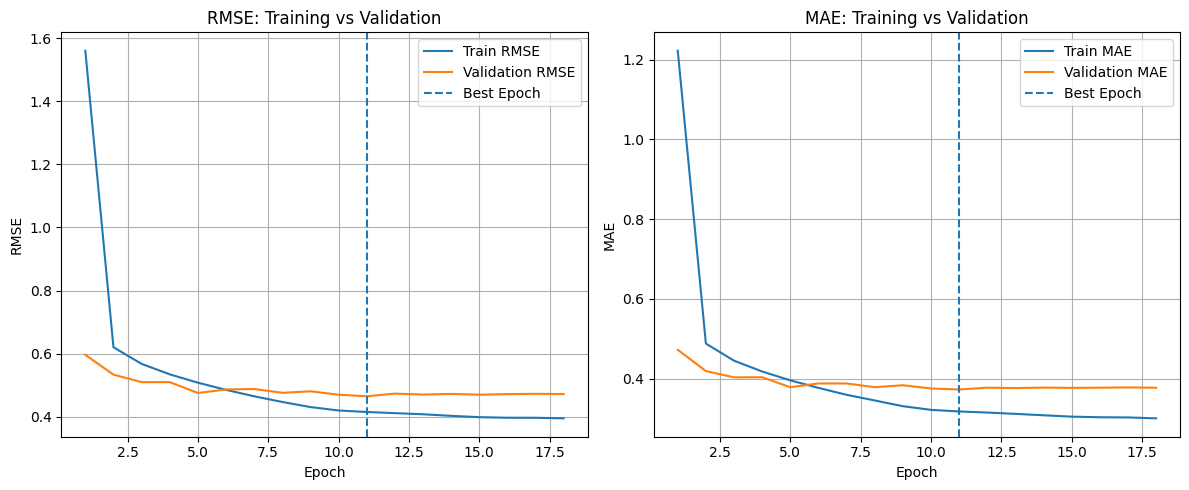

In [27]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [28]:
def collect_predictions(model, df, loader):
    model.eval()

    results = []
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for sensors, labels, idx in pbar:
            sensors = sensors.to(device)

            start = time.time()
            preds = model(sensors)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            batch_time = end - start
            total_time += batch_time
            total_samples += sensors.size(0)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for pred, true, row_idx in zip(preds, labels, idx):
                row = df.iloc[int(row_idx)]
                results.append({
                    "pred": float(pred),
                    "true": float(true),
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)
    metrics = regression_metrics(results_df["true"], results_df["pred"])
    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, metrics["mae"], metrics["rmse"], latency_per_batch, latency_per_sample


In [29]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred))
    }


def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group
    return group_mae, worst_group, gap


def compute_fairness_metrics(results_df):
    metrics = {}

    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")
    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])
    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")
    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics


def baseline_mae(train_df, eval_df):
    mean_pred = train_df["target"].mean()
    median_pred = train_df["target"].median()
    return {
        "mean_baseline_mae": float((eval_df["target"] - mean_pred).abs().mean()),
        "median_baseline_mae": float((eval_df["target"] - median_pred).abs().mean()),
        "train_mean": float(mean_pred),
        "train_median": float(median_pred)
    }


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalSensorGRU(input_dim=SENSOR_INPUT_DIM).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/scratch-local/cfragkiadakis.22826459/ipykernel_2930919/2164482172.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_locat

TemporalSensorGRU(
  (gru): GRU(16, 32, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [34]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}

with open(model_results, "w") as f:
    json.dump(results, f, indent=4)

Evaluating: 100%|██████████| 135/135 [00:01<00:00, 87.75it/s] 
/scratch-local/cfragkiadakis.22826459/ipykernel_2930919/1352245057.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.22826459/ipykernel_2930919/1352245057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.22826459/ipykernel_2930919/1352245057.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on th

In [35]:
print('MAE:', results['mae'])

MAE: 0.3205


In [36]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.30398, 'male': 0.36396}

Worst-group MAE: 0.36396
Gap: 0.05997


In [37]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.30862, '(17, 20]': 0.20769, '(20, 22]': 0.34683, '(22, 26]': 0.37863, '(26, 44]': 0.25602}

Worst-group MAE: 0.37863
Gap: 0.17093


In [38]:
print("Validation baselines:", baseline_mae(train_df, val_df))
print("Test baselines:", baseline_mae(train_df, test_df))

Validation baselines: {'mean_baseline_mae': 0.3598252937714197, 'median_baseline_mae': 0.3483611930514585, 'train_mean': 2.9282964918068846, 'train_median': 3.0}
Test baselines: {'mean_baseline_mae': 0.3245663172776027, 'median_baseline_mae': 0.3063919627256843, 'train_mean': 2.9282964918068846, 'train_median': 3.0}


In [42]:
preds = results_df['pred']
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

2.307492733001709
3.9018137454986572
2.8844327079742955
0.17412130782906243
